<a href="https://colab.research.google.com/github/MarcelinaBytes/AIHC5020/blob/main/AIHC5020_hw2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **This project implements Ordinary Least Squares regression from scratch with robust input validation, NaN imputation, and visualization using NumPy and Matplotlib.**

Problem 1: The Falsy Value Generator

1. def to_falsy(value)
2. if input value is primitive, it must return equvalent of the same type
3. if input value is not primitive, it must give this message "non primitive type input" and return 'none'



In [7]:
def to_falsy(value):
  # handle none
  if value is None:
    return None

  # Bool is a subclass of int
  if type(value) is bool:
    return False

  #primitive types
  if type(value) is int:
    return 0
  if type(value) is float:
    return 0.0
  if type(value) is str:
    return ""
  if type(value) is complex:
    return 0j

  #nonprimitive types (list, dict,tuple)
  print("non primitive type input")
  return None

In [9]:
# A list of values to test your function
challenge_cases = [
    42,             # Integer
    3.14159,        # Float
    "Python",       # String
    True,           # Boolean
    (1 + 2j),       # Complex
    None,           # NoneType
    [1, 2, 3],      # List (non-primitive)
    ('a', 'b'),     # Tuple (non-primitive)
    {'key': 'val'}  # Dictionary (non-primitive)
]

# Your code to iterate and print results goes here

for item in challenge_cases:
  print(item, "->", to_falsy(item))

42 -> 0
3.14159 -> 0.0
Python -> 
True -> False
(1+2j) -> 0j
None -> None
non primitive type input
[1, 2, 3] -> None
non primitive type input
('a', 'b') -> None
non primitive type input
{'key': 'val'} -> None


Problem 2: Type Inspector and Operator Analysis

In [18]:
def inspect_operations(arg1, arg2):
  # 1. print the type of arg1
  print(type(arg1))

  #2. print type of arg2
  print(type(arg2))

  #3. analyze addition
  try:
    print(arg1 + arg2)
  except TypeError:
    print("cannot add")

  #4. analyze multiplication
  try:
    print(arg1 * arg2)
  except TypeError:
    print ("cannot multiply")

  #5 analyze coercion
  try:
    print(arg2)(arg1)
    print("can coerce")
  except (TypeError, ValueError):
    print("cannot coerce")

In [19]:
inspect_operations(10, 5)

<class 'int'>
<class 'int'>
15
50
5
cannot coerce


In [20]:
inspect_operations(3, "hello")

<class 'int'>
<class 'str'>
cannot add
hellohellohello
hello
cannot coerce


In [21]:
# A list of argument pairs to test your function
challenge_cases = [
    (10.5, 2),
    ("repeat", 4),
    (True, 5),
    ([1, 2], 3),
    ("fizz", "buzz"),
    (None, "a_string"),
    ({'a': 1}, 2)
]

# Your code to iterate and test goes here.
# For each 'case' in the list, you can call your function
# like this: inspect_operations(*case)

for case in challenge_cases:
  inspect_operations(*case)
  print("-----")

<class 'float'>
<class 'int'>
12.5
21.0
2
cannot coerce
-----
<class 'str'>
<class 'int'>
cannot add
repeatrepeatrepeatrepeat
4
cannot coerce
-----
<class 'bool'>
<class 'int'>
6
5
5
cannot coerce
-----
<class 'list'>
<class 'int'>
cannot add
[1, 2, 1, 2, 1, 2]
3
cannot coerce
-----
<class 'str'>
<class 'str'>
fizzbuzz
cannot multiply
buzz
cannot coerce
-----
<class 'NoneType'>
<class 'str'>
cannot add
cannot multiply
a_string
cannot coerce
-----
<class 'dict'>
<class 'int'>
cannot add
cannot multiply
2
cannot coerce
-----


Problem 3: Even and Odd Integer Sorter

In [41]:
def sort_and_separate_integers(data):
    #1. input validation must be a list
    if type(data) is not list:
        print("not a list")
        return None
    evens = []
    odds = []

    #2.element processing
    for i in range(len(data)):
        item=data[i]

        #must be int but exclude boolean
        if type(item) is not int:
            print(f"non-integer entry found at index {i}: {data[i]}")
            continue

        #separate even vs odd
        if item % 2 == 0:
            evens.append(item)
        else:
            odds.append(item)

    #3. Sort lists ascending
    evens.sort()
    odds.sort()

    #4. Return tuple of two lines
    return(evens,odds)

In [42]:
print(sort_and_separate_integers([4, 3, 7, 10, 1, 8]))
print("-----")
print(sort_and_separate_integers([1, "hello", 2, 4]))
print("-----")
print(sort_and_separate_integers("this is not a list"))


([4, 8, 10], [1, 3, 7])
-----
non-integer entry found at index 1: hello
([2, 4], [1])
-----
not a list
None


In [43]:
# A list of inputs to test your function
challenge_cases = [
    [5, -2, 2, 5, "skip", -3, 8], # Mixed types, negatives, and duplicates
    [],                           # An empty list
    [10, 2, 88, 4],               # Only even integers
    [9, 15, 1, 3],                # Only odd integers
    ['a', None, 3.14, True],      # No valid integers (Note: True is a bool, not an int for this problem)
    (1, 2, 3),                    # A tuple, not a list
    [10]                          # A list with a single element
]

# Your code to iterate and test goes here.
# For each 'case' in the list, call your function
# and print the returned value.

for case in challenge_cases:
  result = sort_and_separate_integers(case)
  print("Returned:", result)
  print("-----")

non-integer entry found at index 4: skip
Returned: ([-2, 2, 8], [-3, 5, 5])
-----
Returned: ([], [])
-----
Returned: ([2, 4, 10, 88], [])
-----
Returned: ([], [1, 3, 9, 15])
-----
non-integer entry found at index 0: a
non-integer entry found at index 1: None
non-integer entry found at index 2: 3.14
non-integer entry found at index 3: True
Returned: ([], [])
-----
not a list
Returned: None
-----
Returned: ([10], [])
-----


Problem 4: Set Operations on Lists

In [68]:
def analyze_list_sets(l0, l1):
  if type(l0) is not list:
        print(f"invalid input: {l0}")
        return None
  if type(l1) is not list:
        print(f"invalid input: {l1}")
        return None

  #Check primitive types exactly as listed
  primitive_types = (int, float, str, bool, complex, type(None))

  #2. Input Validation (Elements) + filtering
  valid0 = []
  for i in range(len(l0)):
    if type(l0[i]) not in primitive_types:
      print(f"invalid entry at index {i} in l0: {l0[i]}")
    else:
      valid0.append(l0[i])

  valid1 = []
  for i in range(len(l1)):
    if type(l1[i]) not in primitive_types:
      print(f"invalid entry at index {i} in l1: {l1[i]}")
    else:
      valid1.append(l1[i])

    #3. Return Value
  set0 = set(valid0)
  set1 = set(valid1)

  inter = set0.intersection(set1)
  symdiff = set0.symmetric_difference(set1)

  #Sorting safely
  def sort_key(x):
    return(type(x).__name__,repr(x))

  return(sorted(inter, key =sort_key), sorted(symdiff, key = sort_key))

In [69]:
print(analyze_list_sets([1, 'a', 3], [3, 'b', 'a']))
print("-----")
print(analyze_list_sets([1, 2], "not-a-list"))
print("-----")
print(analyze_list_sets([1, [99], 2, 3], [2, 4, 3]))


([3, 'a'], [1, 'b'])
-----
invalid input: not-a-list
None
-----
invalid entry at index 1 in l0: [99]
([2, 3], [1, 4])


In [70]:
# A list of argument pairs to test your function
challenge_cases = [
    ([1, 'a', 2.0], ['a', 3, 2.0]),
    ([1, 2], [1, 2, 3, 4]),
    ([1, None, {'k':'v'}], [1, 2, None]),
    ([1, 2, 3], [4, 5, 6]),
    ([], [1, 2, 3]),
    ("not a list", [1, 2]),
    ([1, 2], [1, 2])
]

# Your code to iterate and test goes here.
# For each 'case' in challenge_cases, you can call your function
# like this: analyze_list_sets(*case)

for case in challenge_cases:
  print(analyze_list_sets(*case))
  print("-----")

([2.0, 'a'], [1, 3])
-----
([1, 2], [3, 4])
-----
invalid entry at index 2 in l0: {'k': 'v'}
([None, 1], [2])
-----
([], [1, 2, 3, 4, 5, 6])
-----
([], [1, 2, 3])
-----
invalid input: not a list
None
-----
([1, 2], [])
-----


Problem 5: NumPy Array Statistical Summary

In [72]:
import numpy as np

def summarize_numpy_array(arr):
  # 1) input validation
    if not isinstance(arr, np.ndarray) or arr.ndim != 1 or not np.issubdtype(arr.dtype, np.floating):
        print("invalid input")
        return None

    # 2) empty array edge case
    if arr.size == 0:
        return {
            "min": None, "mean": None, "max": None, "std_dev": None,
            "p25": None, "p50": None, "p75": None, "iqr": None
        }

    # 3) return value
    p25 = np.percentile(arr, 25)
    p50 = np.percentile(arr, 50)
    p75 = np.percentile(arr, 75)

    return {
        "min": float(np.min(arr)),
        "mean": float(np.mean(arr)),
        "max": float(np.max(arr)),
        "std_dev": float(np.std(arr)),
        "p25": float(p25),
        "p50": float(p50),
        "p75": float(p75),
        "iqr": float(p75 - p25),
    }

In [73]:
import numpy as np
data = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
summarize_numpy_array(data)

{'min': 1.0,
 'mean': 3.0,
 'max': 5.0,
 'std_dev': 1.4142135623730951,
 'p25': 2.0,
 'p50': 3.0,
 'p75': 4.0,
 'iqr': 2.0}

In [74]:
summarize_numpy_array([1.0, 2.0, 3.0])

invalid input


In [75]:
import numpy as np

# A list of inputs to test your function
challenge_cases = [
    np.array([10.5, 2.3, -5.7, 8.1, 0.0, 3.9]), # Standard case with negatives
    np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]), # Another valid case
    np.array([], dtype=np.float64),              # Edge case: empty but valid array
    [1.0, 2.0, 3.0],                             # Invalid: Python list
    np.array([[1.0, 2.0], [3.0, 4.0]]),          # Invalid: 2D array
    np.arange(5)                                 # Invalid: integer dtype
]

# Your code to iterate and test goes here.

for case in challenge_cases:
  print(summarize_numpy_array(case))
  print("-----")

{'min': -5.7, 'mean': 3.183333333333333, 'max': 10.5, 'std_dev': 5.2922637458421855, 'p25': 0.575, 'p50': 3.0999999999999996, 'p75': 7.05, 'iqr': 6.475}
-----
{'min': 1.0, 'mean': 4.5, 'max': 8.0, 'std_dev': 2.29128784747792, 'p25': 2.75, 'p50': 4.5, 'p75': 6.25, 'iqr': 3.5}
-----
{'min': None, 'mean': None, 'max': None, 'std_dev': None, 'p25': None, 'p50': None, 'p75': None, 'iqr': None}
-----
invalid input
None
-----
invalid input
None
-----
invalid input
None
-----


In [ ]:
Problem 6: Scatter Plot with NaN Imputation using Masked Arrays

In [89]:
import numpy as np
import matplotlib.pyplot as plt

def create_scatter_plot(x_arr, y_arr):

  #1. input validation
  if not isinstance(x_arr, np.ndarray) or not isinstance(y_arr, np.ndarray):
        print("invalid input")
        return
  if x_arr.ndim != 1 or y_arr.ndim != 1:
        print("invalid input")
        return
  if x_arr.dtype.kind != "f" or y_arr.dtype.kind != "f":
        print("invalid input")
        return

  if len(x_arr) != len(y_arr):
        print("arrays are not the same size.")
        return

  #2. missing value
  mx = np.ma.masked_invalid(x_arr)
  my = np.ma.masked_invalid(y_arr)

  x_mean = mx.mean()
  y_mean = my.mean()

    # If an array is ALL NaNs, mean() is masked; fill with np.nan
  if np.ma.is_masked(x_mean):
        x_mean = np.nan
  if np.ma.is_masked(y_mean):
        y_mean = np.nan

  x_filled = mx.filled(x_mean)
  y_filled = my.filled(y_mean)

  #3. plotting
  plt.figure()
  plt.scatter(x_filled, y_filled)
  plt.title("Scatter Plot of X vs Y")
  plt.xlabel("X Values (Imputed)")
  plt.ylabel("Y Values (Imputed)")
  plt.show()

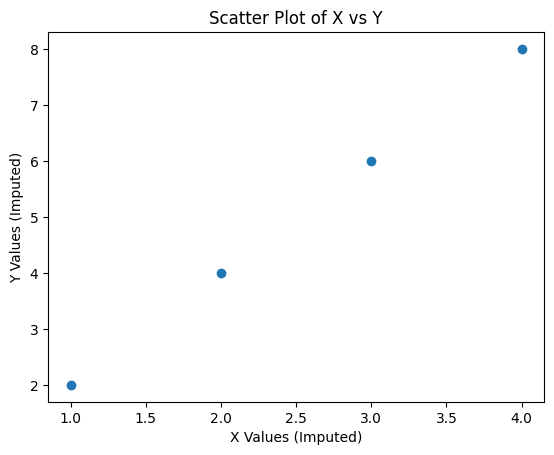

In [90]:
import numpy as np
x = np.array([1.0, 2.0, 3.0, 4.0])
y = np.array([2.0, 4.0, 6.0, 8.0])
create_scatter_plot(x, y)

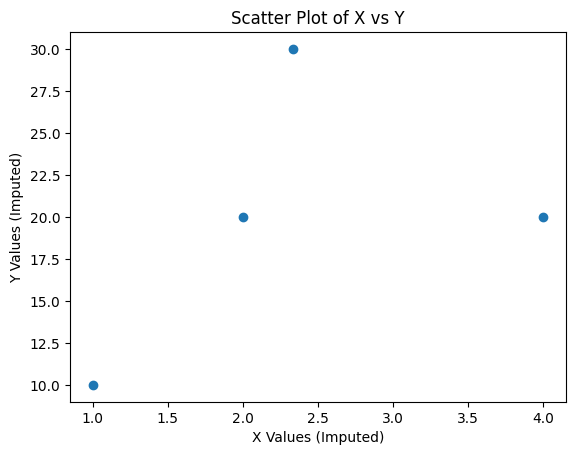

In [91]:
import numpy as np
x = np.array([1.0, 2.0, np.nan, 4.0]) # Mean of non-missing is (1+2+4)/3 = 2.33
y = np.array([10.0, 20.0, 30.0, np.nan]) # Mean of non-missing is (10+20+30)/3 = 20.0
create_scatter_plot(x, y)

In [92]:
import numpy as np
x = np.array([1.0, 2.0, 3.0])
y = np.array([1.0, 2.0])
create_scatter_plot(x, y)

arrays are not the same size.


--- Case 1 ---


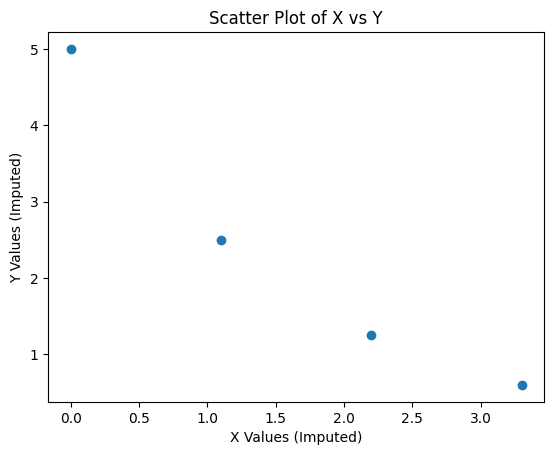

-----
--- Case 2 ---


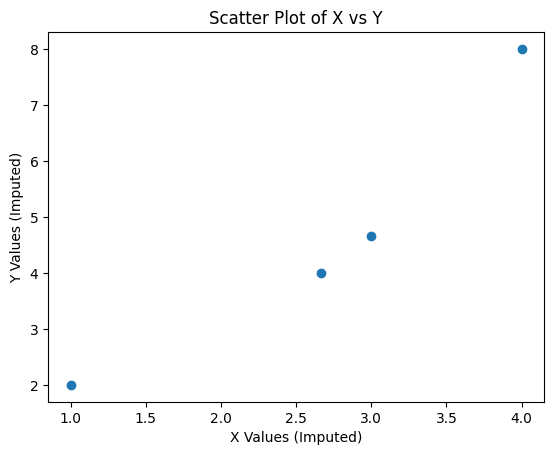

-----
--- Case 3 ---
arrays are not the same size.
-----
--- Case 4 ---
invalid input
-----
--- Case 5 ---


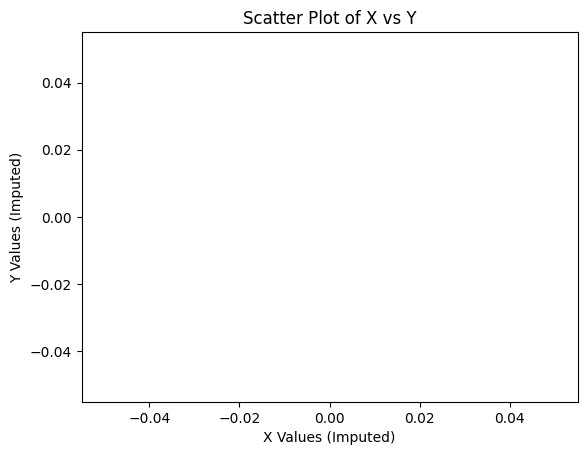

-----


In [93]:
import numpy as np
import matplotlib.pyplot as plt

# A list of argument pairs to test your function
challenge_cases = [
    (np.array([0.0, 1.1, 2.2, 3.3]), np.array([5.0, 2.5, 1.25, 0.6])), # Standard case
    (np.array([1.0, np.nan, 3.0, 4.0]), np.array([2.0, 4.0, np.nan, 8.0])), # NaNs in both
    (np.array([1.0, 2.0]), np.array([1.0, 2.0, 3.0])),                     # Different lengths
    ([1.0, 2.0], np.array([3.0, 4.0])),                                   # Invalid type (list)
    (np.arange(4, dtype=float), np.array([np.nan, np.nan, np.nan, np.nan])) # All NaNs in one array
]

# Your code to iterate and test goes here.
# For each 'case' in challenge_cases, call your function.
# Matplotlib will pause execution until you close each plot window.

for idx, (x, y) in enumerate(challenge_cases, start=1):
    print(f"--- Case {idx} ---")
    create_scatter_plot(x, y)
    print("-----")


Problem 7: Simple Linear Regression from Scratch


In [98]:
import numpy as np

def calculate_regression(x,y):
    #1) Input validation: must be numpy arrays
    if not isinstance(x, np.ndarray) or not isinstance(y, np.ndarray):
        print("invalid input")
        return None

    #must be 1D
    if x.ndim != 1 or y.ndim != 1:
        print("invalid input")
        return None

    #must be float dtype
    if x.dtype.kind != "f" or y.dtype.kind != "f":
        print("invalid input")
        return None

    #2) Same length check
    if len(x) != len(y):
        print("x and y are not the same length")
        return None

    #3) Missing value imputation
    x2 = x.copy()
    y2 = y.copy()

    # mean of non-missing values
    x_mean = np.nanmean(x2)
    y_mean = np.nanmean(y2)

    # replace NaNs with mean
    x2 = np.where(np.isnan(x2), x_mean, x2)
    y2 = np.where(np.isnan(y2), y_mean, y2)

    # 4) OLS slope/intercept
    x_bar = x2.mean()
    y_bar = y2.mean()

    numerator = np.sum((x2 - x_bar) * (y2 - y_bar))
    denominator = np.sum((x2 - x_bar) ** 2)

    # protect against divide-by-zero (all x the same)
    if denominator == 0:
        # safest: flat line at mean y
        return (0.0, float(y_bar))

    m = numerator / denominator
    b = y_bar - m * x_bar

    return (float(m), float(b))


In [99]:
import numpy as np
x = np.array([1.0, 2.0, 3.0, 4.0])
y = np.array([2.0, 4.0, 5.0, 8.0])
calculate_regression(x, y)

(1.9, 0.0)

In [100]:
import numpy as np
x = np.array([1.0, 2.0, np.nan]) # Imputed x becomes [1., 2., 1.5]
y = np.array([2.0, np.nan, 6.0]) # Imputed y becomes [2., 4., 6.]
calculate_regression(x, y)

(2.0, 1.0)

In [101]:
import numpy as np
x = np.array([1.0, 2.0, 3.0])
y = np.array([1.0, 2.0])
calculate_regression(x, y)

x and y are not the same length


In [103]:
import numpy as np

# A list of argument pairs to test your function
challenge_cases = [
    (np.array([1.0, 2.0, 4.0, 5.0]), np.array([1.0, 3.0, 3.0, 5.0])), # Standard case
    (np.array([1.0, 2.0, 3.0, np.nan]), np.array([5.0, 4.0, np.nan, 2.0])), # NaNs in both
    (np.array([1.0, 2.0]), np.array([1.0, 2.0, 3.0])),                     # Different lengths
    ([1.0, 2.0], np.array([3.0, 4.0])),                                   # Invalid type (list)
    (np.arange(4, dtype=float), np.array([5.0, 5.0, 5.0, 5.0])),           # Horizontal line
    (np.array([5.0, 5.0, 5.0, 5.0]), np.arange(4, dtype=float))            # Vertical line
]

# Your code to iterate and test goes here.

for case in challenge_cases:
  print(calculate_regression(*case))
  print("-----")

(0.8, 0.5999999999999996)
-----
(-0.6666666666666667, 5.0)
-----
x and y are not the same length
None
-----
invalid input
None
-----
(0.0, 5.0)
-----
(0.0, 1.5)
-----


Problem 8: Visualizing Linear Regression

In [106]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_regression(x,y):
    #1) Input validation: must be numpy arrays
    if not isinstance(x, np.ndarray) or not isinstance(y, np.ndarray):
        print("invalid input")
        return None

    #must be 1D
    if x.ndim != 1 or y.ndim != 1:
        print("invalid input")
        return None

    #must be float dtype
    if x.dtype.kind != "f" or y.dtype.kind != "f":
        print("invalid input")
        return None

    #2) Same length check
    if len(x) != len(y):
        print("x and y are not the same length")
        return None

    #3) Missing value imputation
    x2 = x.copy()
    y2 = y.copy()

    # mean of non-missing values
    x_mean = np.nanmean(x2)
    y_mean = np.nanmean(y2)

    # replace NaNs with mean
    x2 = np.where(np.isnan(x2), x_mean, x2)
    y2 = np.where(np.isnan(y2), y_mean, y2)

    # 4) OLS slope/intercept
    x_bar = x2.mean()
    y_bar = y2.mean()

    numerator = np.sum((x2 - x_bar) * (y2 - y_bar))
    denominator = np.sum((x2 - x_bar) ** 2)

    # protect against divide-by-zero (all x the same)
    if denominator == 0:
        # safest: flat line at mean y
        return (0.0, float(y_bar))

    m = numerator / denominator
    b = y_bar - m * x_bar

    return (float(m), float(b))

def plot_regression(x, y):

    result = calculate_regression(x, y)
    if result is None:
        return

    slope, intercept = result

    # Detect vertical line (undefined slope)
    if np.isnan(slope):
        print("vertical line detected")
        return None

    # Impute NaNs for plotting (copies)
    x_plot = x.copy()
    y_plot = y.copy()

    x_mean = np.nanmean(x_plot)
    y_mean = np.nanmean(y_plot)

    x_plot[np.isnan(x_plot)] = x_mean
    y_plot[np.isnan(y_plot)] = y_mean

    # Plot
    plt.figure()
    plt.scatter(x_plot, y_plot)
    plt.axline((0, intercept), slope=slope)

    plt.title("Scatter Plot with Regression Line")
    plt.xlabel("X Values")
    plt.ylabel("Y Values")
    plt.show()



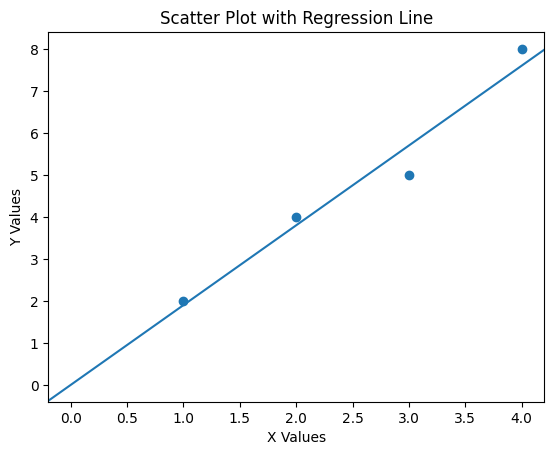

In [107]:
import numpy as np
x = np.array([1.0, 2.0, 3.0, 4.0])
y = np.array([2.0, 4.0, 5.0, 8.0])
plot_regression(x, y)

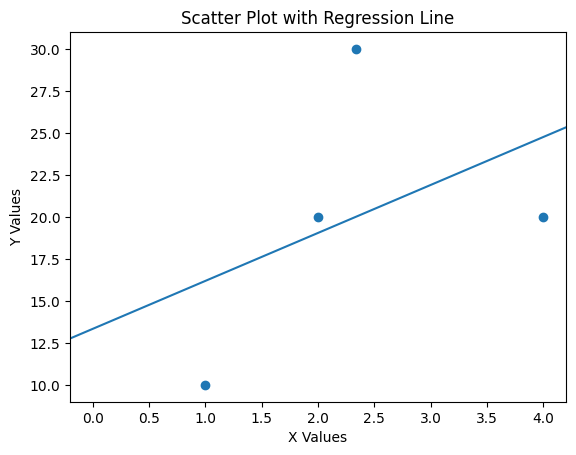

In [111]:
import numpy as np
x = np.array([1.0, 2.0, np.nan, 4.0])
y = np.array([10.0, 20.0, 30.0, np.nan])
plot_regression(x, y)

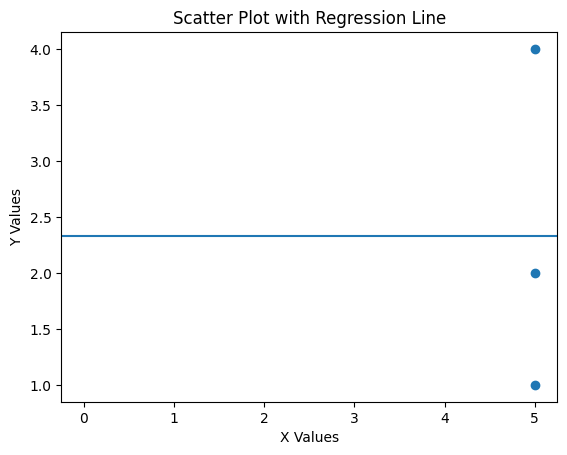

In [113]:
import numpy as np
x = np.array([5.0, 5.0, 5.0])
y = np.array([1.0, 2.0, 4.0])
plot_regression(x, y)

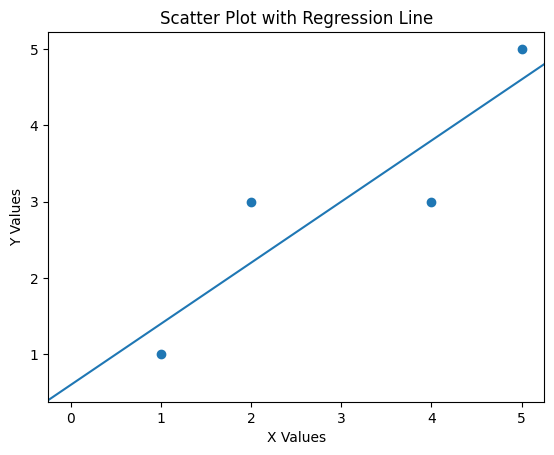

-----


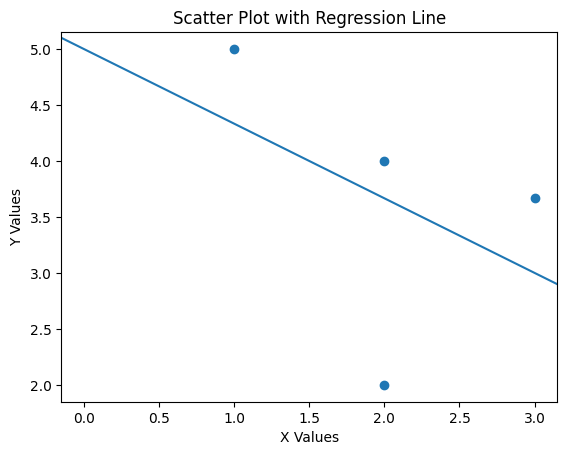

-----
x and y are not the same length
-----


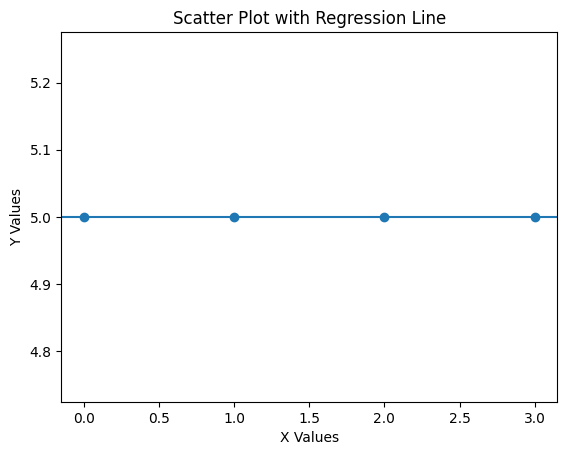

-----


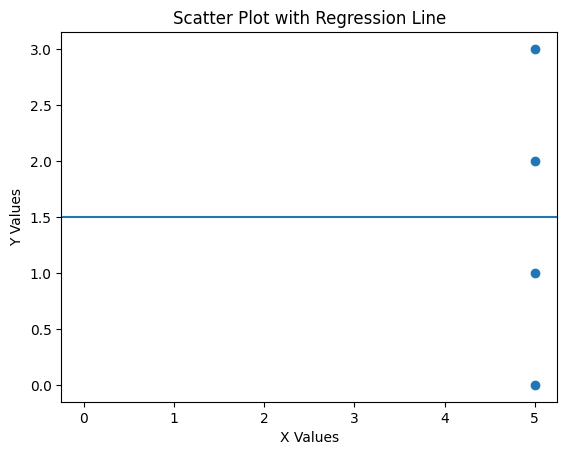

-----


In [114]:
import numpy as np
import matplotlib.pyplot as plt

# A list of argument pairs to test your function
challenge_cases = [
    (np.array([1.0, 2.0, 4.0, 5.0]), np.array([1.0, 3.0, 3.0, 5.0])), # Standard case
    (np.array([1.0, 2.0, 3.0, np.nan]), np.array([5.0, 4.0, np.nan, 2.0])), # NaNs in both
    (np.array([1.0, 2.0]), np.array([1.0, 2.0, 3.0])),                     # Different lengths
    (np.arange(4, dtype=float), np.array([5.0, 5.0, 5.0, 5.0])),           # Horizontal line
    (np.array([5.0, 5.0, 5.0, 5.0]), np.arange(4, dtype=float))            # Vertical line
]

# Your code to iterate and test goes here.

for x_case, y_case in challenge_cases:
    plot_regression(x_case, y_case)
    print("-----")